# Análisis de Evasión de Clientes (Churn)



## Introducción

La evasión de clientes, conocida como **Churn**, es un problema importante para las empresas que ofrecen servicios por suscripción. Cuando un cliente decide cancelar el servicio, la empresa pierde ingresos y debe invertir más recursos para adquirir nuevos clientes.

El objetivo de este análisis es explorar los datos de clientes de una empresa de telecomunicaciones para identificar patrones que puedan explicar por qué algunos clientes cancelan el servicio mientras que otros permanecen.

A través de diferentes técnicas de limpieza de datos, transformación de variables y análisis exploratorio, se busca obtener información que permita comprender mejor el comportamiento de los clientes y apoyar la toma de decisiones estratégicas para mejorar la retención.

## Limpieza y Tratamiento de Datos

Antes de realizar el análisis, fue necesario preparar y limpiar los datos para garantizar su calidad y consistencia.

Durante esta etapa se realizaron los siguientes procesos:

- Importación del dataset y revisión inicial de las variables.
- Estandarización de valores de texto, convirtiéndolos a minúsculas y eliminando espacios innecesarios.
- Conversión de variables categóricas binarias como **Yes/No** a valores numéricos **1 y 0**.
- Codificación de variables categóricas con múltiples categorías mediante **One-Hot Encoding** utilizando `pd.get_dummies()`.
- Conversión de valores booleanos (**True / False**) a valores numéricos.
- Creación de nuevas variables como **Cuentas_Diarias**, calculada a partir de la facturación mensual.

Estos pasos permitieron transformar el dataset en una estructura adecuada para realizar análisis estadísticos y visualizaciones.

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
data = pd.read_json(url)

data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
data = pd.json_normalize(data.to_dict(orient='records'))

In [4]:
#FILAS Y COLUMNAS
data.shape

(7267, 21)

In [5]:
data

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [6]:
data.columns = data.columns.str.split('.').str[-1]

In [7]:
data.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total'],
      dtype='str')

In [8]:
import numpy as np
data['Total'] = pd.to_numeric(data['Total'], errors='coerce')

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   str    
 1   Churn             7267 non-null   str    
 2   gender            7267 non-null   str    
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   str    
 5   Dependents        7267 non-null   str    
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   str    
 8   MultipleLines     7267 non-null   str    
 9   InternetService   7267 non-null   str    
 10  OnlineSecurity    7267 non-null   str    
 11  OnlineBackup      7267 non-null   str    
 12  DeviceProtection  7267 non-null   str    
 13  TechSupport       7267 non-null   str    
 14  StreamingTV       7267 non-null   str    
 15  StreamingMovies   7267 non-null   str    
 16  Contract          7267 non-null   str    
 17  Paperl

In [10]:
data.isnull().sum()

customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Monthly              0
Total               11
dtype: int64

In [11]:
data.describe()

,SeniorCitizen,tenure,Monthly,Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
data['Total'] = data['Total'].fillna(data['Total'].median())

In [13]:
data.isnull().sum()

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64

In [14]:
for col in data.select_dtypes(include='str'):
    print(col)
    print(data[col].unique())
    print()


customerID
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str

Churn
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

PhoneService
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DevicePr

In [15]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

In [16]:
data['Churn'] = data['Churn'].replace('', pd.NA)

In [17]:
data.isna().sum()

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                 0
dtype: int64

In [18]:
data = data.dropna(subset=['Churn'])

In [19]:
data['Churn'].isna().sum()

np.int64(0)

In [20]:
data.duplicated().sum()

np.int64(0)

In [21]:
data['customerID'].duplicated().sum()

np.int64(0)

In [22]:
data.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
5218,7124-UGSUR,Yes,Female,1,Yes,No,61,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),104.40,6405.00
6222,8562-GHPPI,No,Female,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.80,19.80
1088,1543-LLLFT,No,Male,1,Yes,No,61,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,No,One year,Yes,Mailed check,98.30,6066.55
1966,2792-LSHWX,No,Female,0,No,No,1,Yes,No,Fiber optic,...,Yes,No,Yes,No,No,Month-to-month,Yes,Mailed check,83.40,83.40
3888,5318-IXUZF,Yes,Female,0,No,No,2,Yes,No,Fiber optic,...,Yes,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),87.15,183.75


In [23]:
for col in data.select_dtypes(include='str'):
    if col != 'customerID':
        data[col] = data[col].str.lower().str.strip()

In [24]:
data

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.60,593.30
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.90,542.40
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.90,280.85
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.00,1237.85
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,no,female,0,no,no,13,yes,no,dsl,...,no,no,yes,no,no,one year,no,mailed check,55.15,742.90
7263,9992-RRAMN,yes,male,0,yes,no,22,yes,yes,fiber optic,...,no,no,no,no,yes,month-to-month,yes,electronic check,85.10,1873.70
7264,9992-UJOEL,no,male,0,no,no,2,yes,no,dsl,...,yes,no,no,no,no,month-to-month,yes,mailed check,50.30,92.75
7265,9993-LHIEB,no,male,0,yes,yes,67,yes,no,dsl,...,no,yes,yes,no,yes,two year,no,mailed check,67.85,4627.65


In [25]:
data['Cuentas_Diarias'] = round(data['Monthly'] / 30, 2)

In [26]:
data

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.60,593.30,2.19
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.90,542.40,2.00
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.90,280.85,2.46
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,no,female,0,no,no,13,yes,no,dsl,...,no,yes,no,no,one year,no,mailed check,55.15,742.90,1.84
7263,9992-RRAMN,yes,male,0,yes,no,22,yes,yes,fiber optic,...,no,no,no,yes,month-to-month,yes,electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,no,male,0,no,no,2,yes,no,dsl,...,no,no,no,no,month-to-month,yes,mailed check,50.30,92.75,1.68
7265,9993-LHIEB,no,male,0,yes,yes,67,yes,no,dsl,...,yes,yes,no,yes,two year,no,mailed check,67.85,4627.65,2.26


In [27]:
cols_binarias = [
    'Churn','Partner','Dependents','PhoneService','PaperlessBilling'
]

In [28]:
for col in cols_binarias:
    data[col] = data[col].map({'yes':1, 'no':0})



data['gender'] = data['gender'].map({'female':0, 'male':1})

In [29]:
data

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,0,0,0,0,13,1,no,dsl,...,no,yes,no,no,one year,0,mailed check,55.15,742.90,1.84
7263,9992-RRAMN,1,1,0,1,0,22,1,yes,fiber optic,...,no,no,no,yes,month-to-month,1,electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,0,1,0,0,0,2,1,no,dsl,...,no,no,no,no,month-to-month,1,mailed check,50.30,92.75,1.68
7265,9993-LHIEB,0,1,0,1,1,67,1,no,dsl,...,yes,yes,no,yes,two year,0,mailed check,67.85,4627.65,2.26


In [30]:
data = data.drop(columns=['customerID'])

In [31]:
cols = [
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'Contract',
'PaymentMethod'
]

data = pd.get_dummies(data, columns=cols, drop_first=True)

In [32]:
data

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Monthly,Total,...,TechSupport_yes,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,0,1,1,9,1,1,65.60,593.30,...,True,False,True,False,False,True,False,False,False,True
1,0,1,0,0,0,9,1,0,59.90,542.40,...,False,False,False,False,True,False,False,False,False,True
2,1,1,0,0,0,4,1,1,73.90,280.85,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,1,0,13,1,1,98.00,1237.85,...,False,False,True,False,True,False,False,False,True,False
4,1,0,1,1,0,3,1,1,83.90,267.40,...,True,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,1,0,55.15,742.90,...,True,False,False,False,False,True,False,False,False,True
7263,1,1,0,1,0,22,1,1,85.10,1873.70,...,False,False,False,False,True,False,False,False,True,False
7264,0,1,0,0,0,2,1,1,50.30,92.75,...,False,False,False,False,False,False,False,False,False,True
7265,0,1,0,1,1,67,1,0,67.85,4627.65,...,True,False,False,False,True,False,True,False,False,True


In [33]:
data = data.astype(int)

In [34]:
data

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Monthly,Total,...,TechSupport_yes,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,0,1,1,9,1,1,65,593,...,1,0,1,0,0,1,0,0,0,1
1,0,1,0,0,0,9,1,0,59,542,...,0,0,0,0,1,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73,280,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,1,0,13,1,1,98,1237,...,0,0,1,0,1,0,0,0,1,0
4,1,0,1,1,0,3,1,1,83,267,...,1,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,1,0,55,742,...,1,0,0,0,0,1,0,0,0,1
7263,1,1,0,1,0,22,1,1,85,1873,...,0,0,0,0,1,0,0,0,1,0
7264,0,1,0,0,0,2,1,1,50,92,...,0,0,0,0,0,0,0,0,0,1
7265,0,1,0,1,1,67,1,0,67,4627,...,1,0,0,0,1,0,1,0,0,1


## Análisis Exploratorio de Datos

### Distribución de la evasión de clientes

El primer paso del análisis fue observar cómo se distribuye la variable **Churn** dentro del conjunto de datos, con el fin de identificar la proporción de clientes que permanecen en el servicio frente a aquellos que lo cancelan.

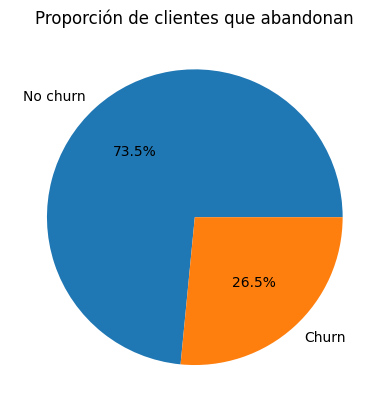

In [35]:
import matplotlib.pyplot as plt
data['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No churn','Churn']
)

plt.title('Proporción de clientes que abandonan')
plt.ylabel('')
plt.show()

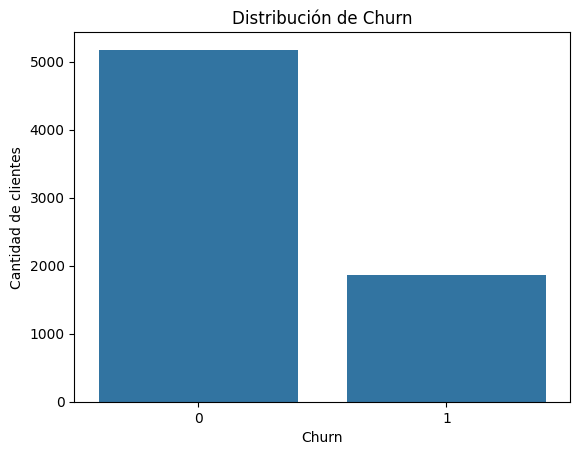

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=data)

plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

### Análisis de variables categóricas

Posteriormente se analizó cómo se relaciona la evasión de clientes con diferentes variables categóricas como el género, el tipo de contrato y el método de pago.

Este análisis permite identificar si ciertos perfiles de clientes presentan una mayor probabilidad de cancelar el servicio.

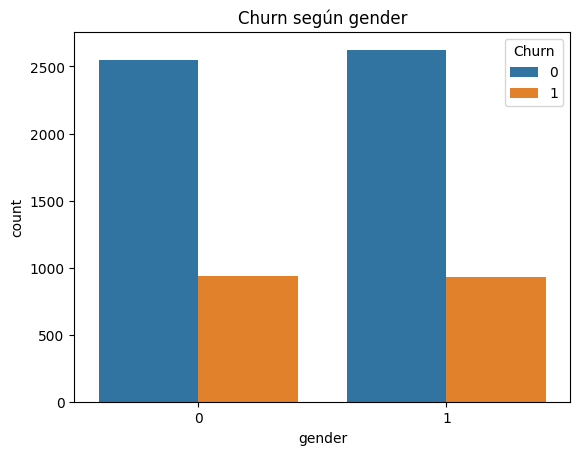

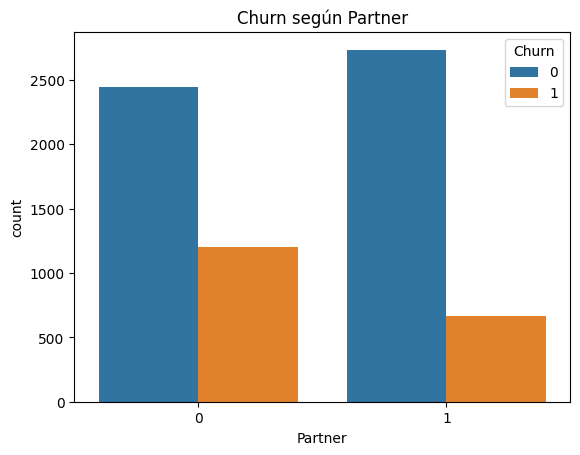

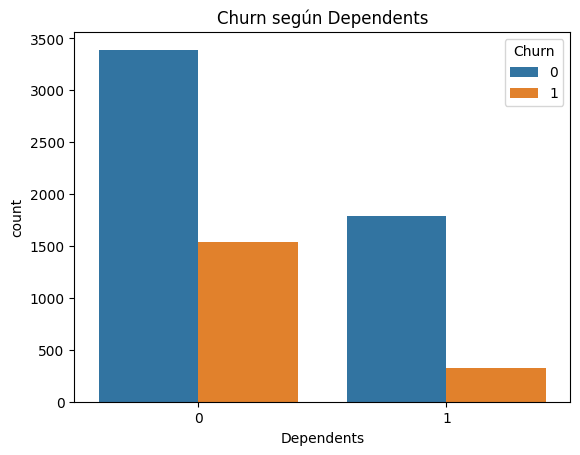

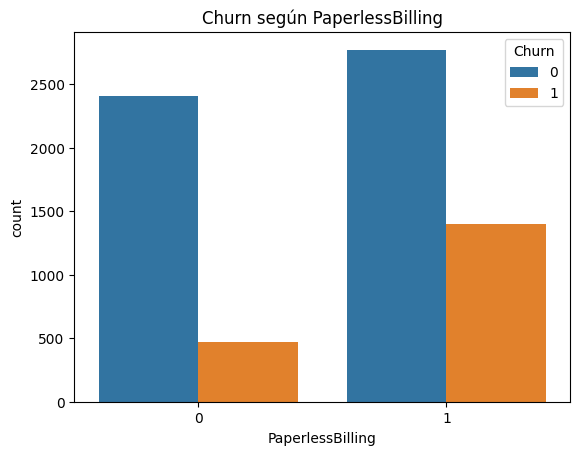

In [38]:
cols = ['gender','Partner','Dependents','PaperlessBilling']

for col in cols:
    sns.countplot(x=col, hue='Churn', data=data)
    plt.title(f'Churn según {col}')
    plt.show()

### Análisis de variables numéricas

También se analizaron variables numéricas como el **tiempo de permanencia del cliente (tenure)**, la **facturación mensual** y el **gasto total**.

Comparar estas variables entre clientes que cancelaron el servicio y los que permanecieron permite identificar posibles patrones relacionados con la evasión.

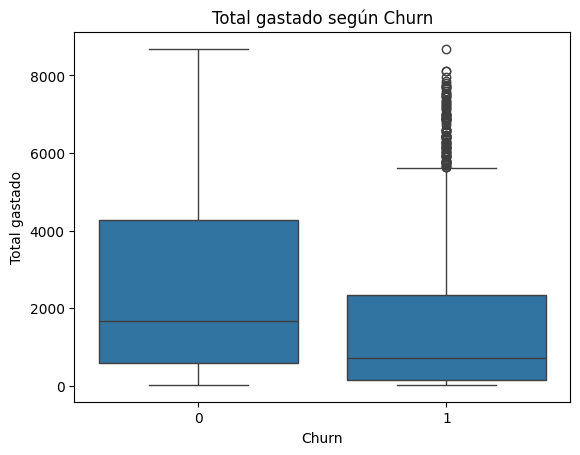

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='Total', data=data)

plt.title('Total gastado según Churn')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

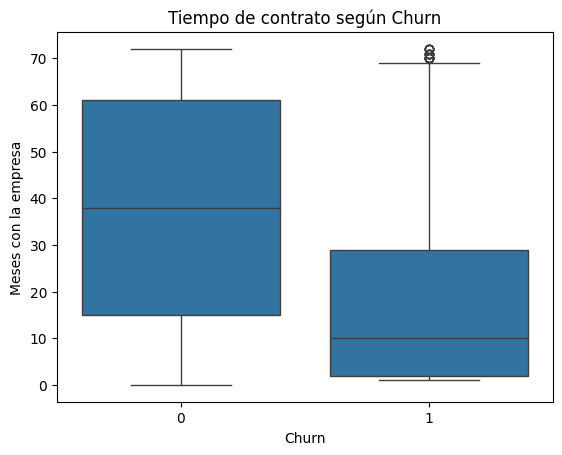

In [40]:
sns.boxplot(x='Churn', y='tenure', data=data)

plt.title('Tiempo de contrato según Churn')
plt.xlabel('Churn')
plt.ylabel('Meses con la empresa')
plt.show()

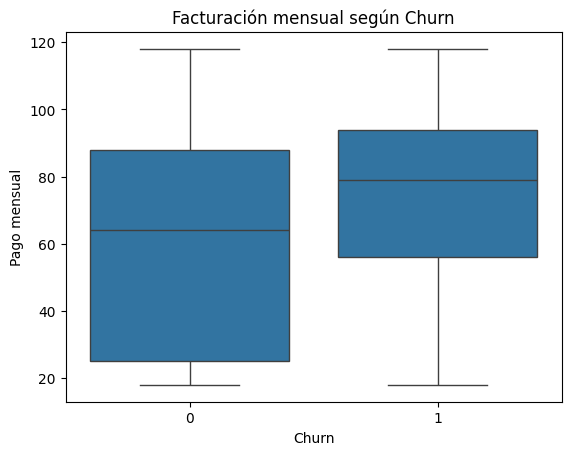

In [41]:
sns.boxplot(x='Churn', y='Monthly', data=data)

plt.title('Facturación mensual según Churn')
plt.xlabel('Churn')
plt.ylabel('Pago mensual')
plt.show()

In [42]:
corr = data.corr()
corr['Churn'].sort_values(ascending=False)

Churn                                    1.000000
InternetService_fiber optic              0.308020
PaymentMethod_electronic check           0.301919
Cuentas_Diarias                          0.196022
Monthly                                  0.193422
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_yes                          0.063228
StreamingMovies_yes                      0.061382
MultipleLines_yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_no phone service          -0.011942
DeviceProtection_yes                    -0.066160
OnlineBackup_yes                        -0.082255
PaymentMethod_mailed check              -0.091683
PaymentMethod_credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_yes                         -0.164674


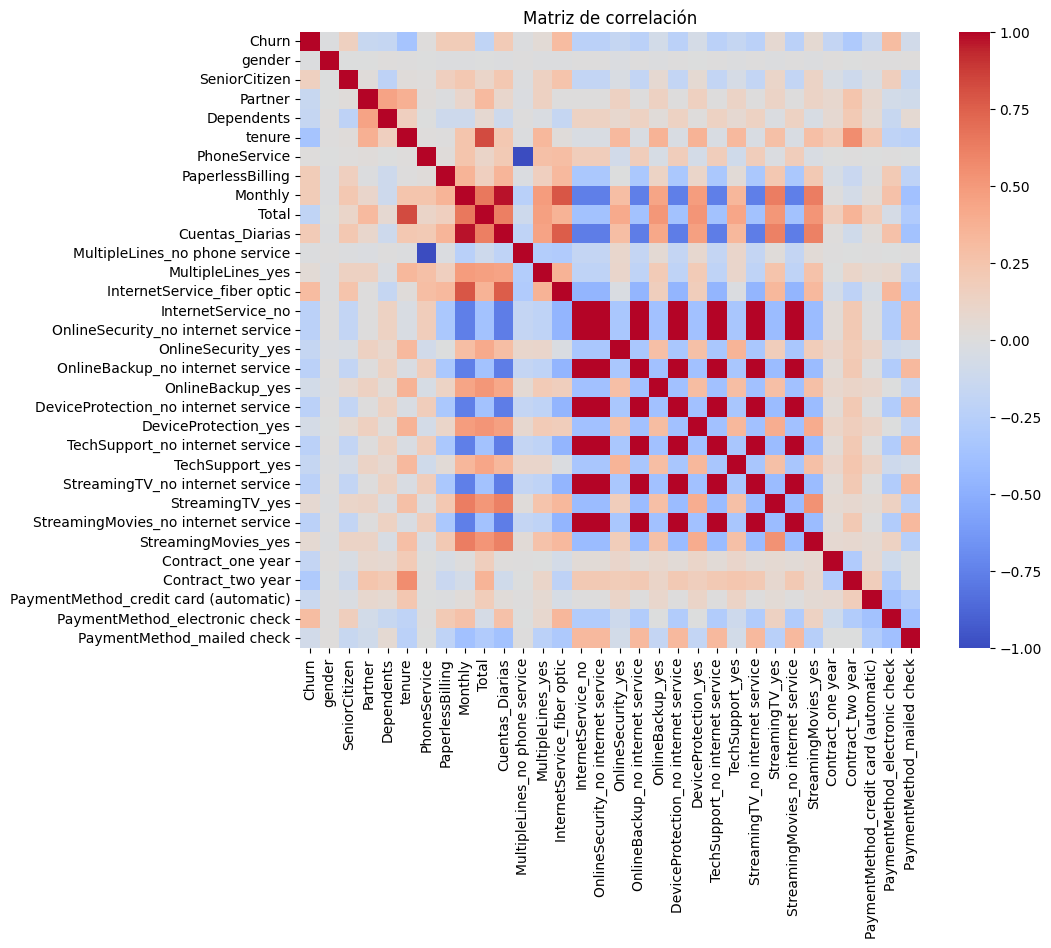

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap='coolwarm')

plt.title('Matriz de correlación')
plt.show()

Como análisis adicional, se exploró la correlación entre las variables del dataset utilizando la función corr() de Pandas. La matriz de correlación permitió identificar qué variables presentan mayor relación con la evasión de clientes. Variables como el tiempo de permanencia y el tipo de contrato mostraron asociaciones relevantes con el churn, lo cual puede ser útil para el desarrollo de modelos predictivos orientados a la retención de clientes.

In [44]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [48]:
y_train.value_counts()

Churn
0    3622
1    1308
Name: count, dtype: int64

In [49]:
y_train_smote.value_counts()

Churn
0    3622
1    3622
Name: count, dtype: int64

## Modelos

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

In [58]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [59]:
from sklearn.metrics import classification_report

print("Regresión Logística")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Regresión Logística
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1552
           1       0.50      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1552
           1       0.64      0.52      0.57       561

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.80      0.79      2113



## Modelos Predictivos

Se desarrollaron dos modelos de clasificación para predecir la cancelación de clientes.

### Regresión Logística

Este modelo requiere normalización de los datos debido a su sensibilidad a la escala de las variables.

**Resultados principales:**

- **Accuracy:** 74%
- **Recall para churn:** 0.80

Esto significa que el modelo logra identificar aproximadamente **el 80% de los clientes que cancelan el servicio**, lo cual es valioso para estrategias de retención.

## Factores que más influyen en la cancelación

A partir del análisis exploratorio y del comportamiento de los modelos, se identificaron algunos factores clave asociados al churn:

- **Bajo tiempo de permanencia (tenure)**  
  Los clientes con pocos meses en la empresa tienen mayor probabilidad de cancelar.

- **Bajo gasto acumulado**  
  Clientes que han generado menor gasto total tienden a abandonar el servicio más rápidamente.

- **Tipo de contrato**  
  Contratos de corto plazo suelen presentar mayor riesgo de cancelación que contratos de largo plazo.

- **Cantidad de servicios contratados**  
  Clientes con menos servicios adicionales muestran mayor probabilidad de cancelar.

## Recomendaciones

Con base en los resultados obtenidos, se proponen algunas estrategias para reducir la evasión de clientes:

- Promover **contratos de mayor duración**, ofreciendo incentivos o descuentos para clientes que opten por planes anuales.
- Implementar **programas de fidelización para nuevos clientes**, especialmente durante los primeros meses de servicio.
- Analizar los **métodos de pago asociados a mayor churn** para identificar posibles mejoras en la experiencia de pago.
- Desarrollar **estrategias de retención personalizadas** para clientes con mayor riesgo de cancelación.

Aplicar estas estrategias podría ayudar a mejorar la satisfacción del cliente y reducir la tasa de evasión.